In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression ,LinearRegression


In [35]:
df = pd.read_csv('SampleSuperstore.csv', encoding='latin1')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [36]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [38]:
# date and Time

print(df['Order Date'].dtypes)

df['Order Date'] = pd.to_datetime(df['Order Date'])
print(df['Order Date'].dtypes)

object
datetime64[ns]


In [39]:
# X = df[['Sales', 'Quantity', 'Discount']]

# Y = df['Profit']

# model = LinearRegression()

# model.fit(X, Y)
# pred = model.predict()

In [40]:
## How many total orders are present in the dataset?


total_orders = df['Order ID'].nunique()
print(f'Total Orders: {total_orders}')

Total Orders: 5009


In [41]:
## How many unique customers are there?

Unique_cust = df['Customer ID'].nunique()
print(f'Unique Customers: {Unique_cust}')

Unique Customers: 793


State with highest sales: California


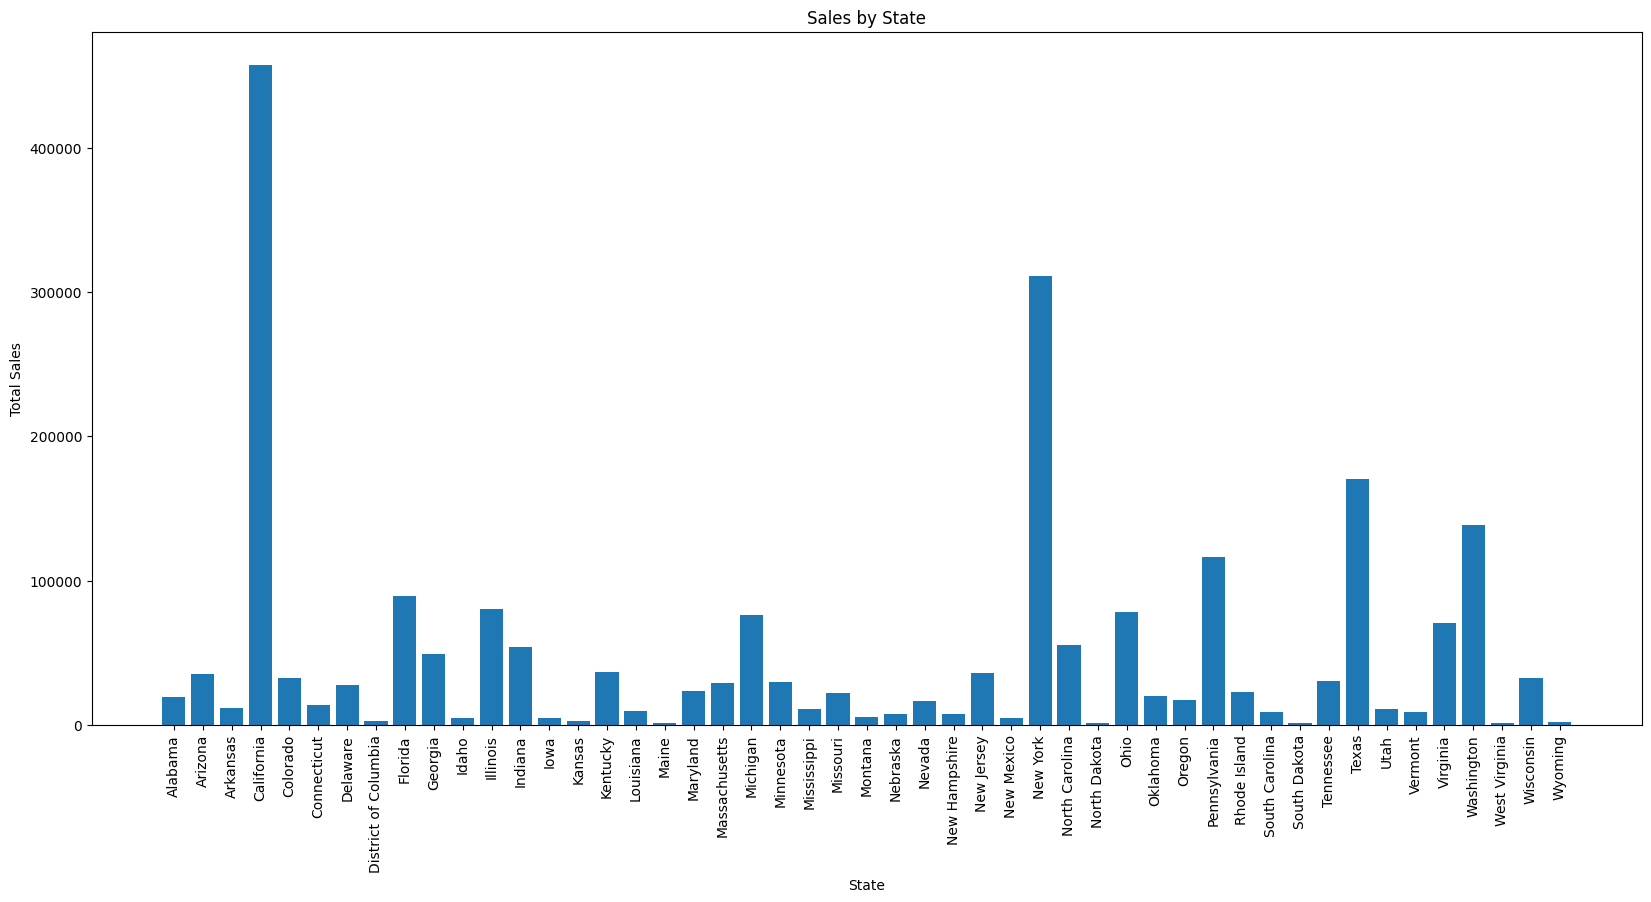

In [ ]:
## Which state has the highest sales?

high_sale = df.groupby('State')['Sales'].sum()  # age wale ('state') joki indx hai and sales jo hai wo values hai
print(f"State with highest sales: {high_sale.idxmax()}")


plt.figure(figsize=(20, 9))
plt.bar(high_sale.index, high_sale.values)
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.title("Sales by State")
plt.xticks(rotation=90)
plt.show()


In [43]:
## Which city generated the maximum profit?
city_profit = df.groupby("City")["Profit"].sum()

max_profit_city = city_profit.idxmax()      # City name
max_profit = city_profit.max()              # Profit value

print(f"City with maximum profit: {max_profit_city}")
print(f"Total Profit: {max_profit}")

City with maximum profit: New York City
Total Profit: 62036.9837


In [44]:
## Which category has the highest total sales?

category_sales = df.groupby("Category")["Sales"].sum()

max_sales_category = category_sales.idxmax()      # Category name
max_sales = category_sales.max()                  # Sales value

print(f"Category with highest sales: {max_sales_category}")
print(f"Total Sales: {max_sales}")

Category with highest sales: Technology
Total Sales: 836154.033


Sub-Category with highest profit: Copiers
Total Profit: 55617.8249


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'Accessories'),
  Text(1, 0, 'Appliances'),
  Text(2, 0, 'Art'),
  Text(3, 0, 'Binders'),
  Text(4, 0, 'Bookcases'),
  Text(5, 0, 'Chairs'),
  Text(6, 0, 'Copiers'),
  Text(7, 0, 'Envelopes'),
  Text(8, 0, 'Fasteners'),
  Text(9, 0, 'Furnishings'),
  Text(10, 0, 'Labels'),
  Text(11, 0, 'Machines'),
  Text(12, 0, 'Paper'),
  Text(13, 0, 'Phones'),
  Text(14, 0, 'Storage'),
  Text(15, 0, 'Supplies'),
  Text(16, 0, 'Tables')])

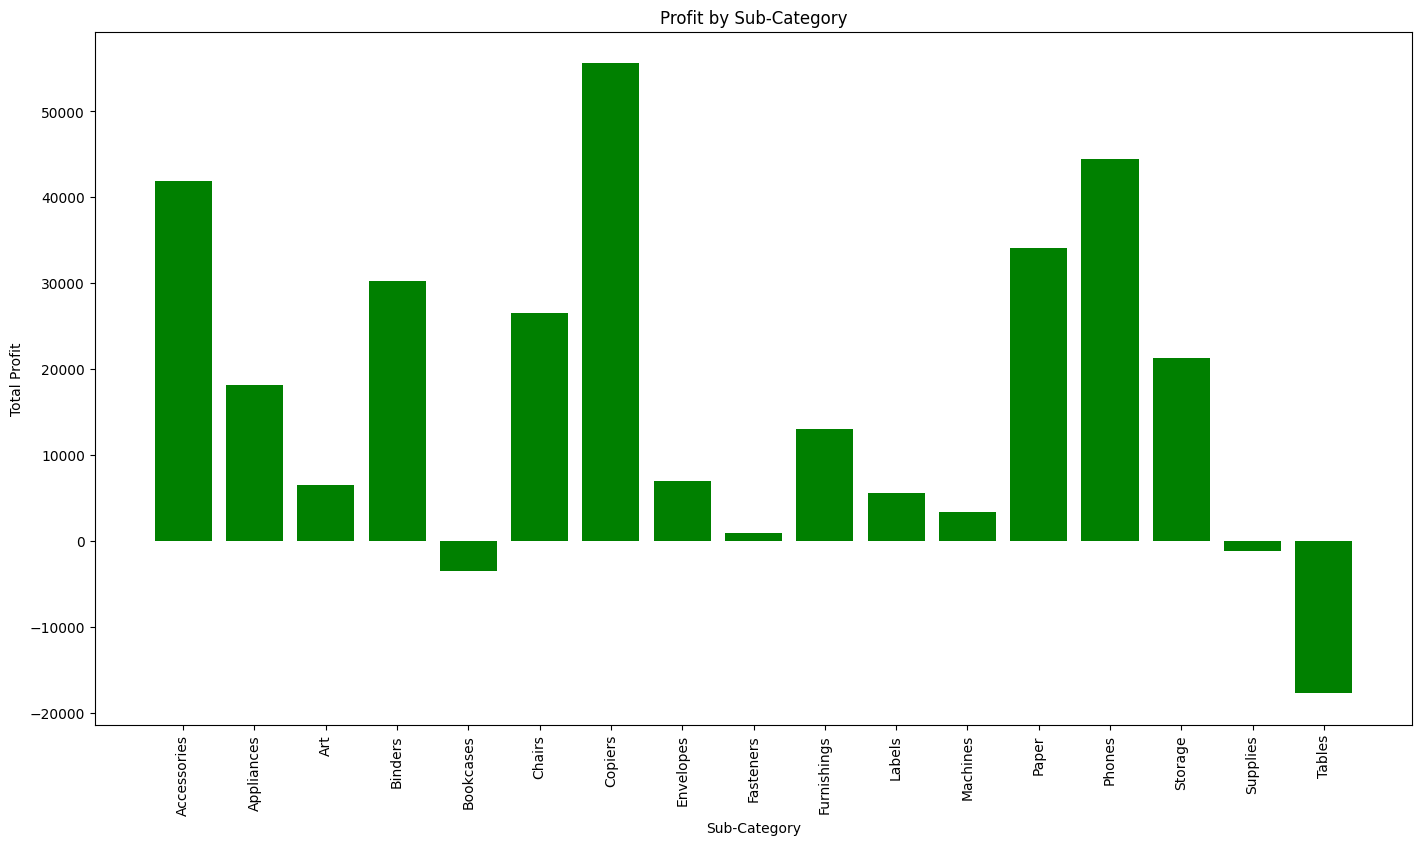

In [54]:
## Which sub-category has the highest profit?

sub_category_profit = df.groupby("Sub-Category")["Profit"].sum()

max_profit_sub_category = sub_category_profit.idxmax()      # Sub-Category name
max_profit = sub_category_profit.max()                        # Profit value

print(f"Sub-Category with highest profit: {max_profit_sub_category}")
print(f"Total Profit: {max_profit}")


plt.figure(figsize=(17, 9))
plt.bar(sub_category_profit.index , sub_category_profit.values , color = 'green')
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.title("Profit by Sub-Category")
plt.xticks(rotation=90)

In [ ]:
# Which ship mode is used most frequently?

df['Ship Mode'].